In [25]:
import numpy as np
import pandas as pd

def compute_penalties_from_constraints(freq, S31, S21, deltaA, bands):
    freq = np.asarray(freq)
    S31 = np.asarray(S31)
    S21 = np.asarray(S21)
    dA  = np.asarray(deltaA)
    penalties = np.zeros((5, len(bands)), dtype=float)

    def band_idx(band):
        fmin, fmax = band
        return np.where((freq >= fmin) & (freq <= fmax))[0]

    def frac_true(boolarr):
        if boolarr.size == 0:
            return 0.0
        return float(np.mean(boolarr.astype(float)))

    for j, band in enumerate(bands):
        idx = band_idx(band)
        S31_r = S31[idx]
        S21_r = S21[idx]
        dA_r  = dA[idx]

        ok0 = (S31_r > -3.5) & (S31_r < -2.5)
        penalties[0, j] = 1.0 - frac_true(ok0)

        ok1 = (S21_r > -3.5) & (S21_r < -2.5)
        penalties[1, j] = 1.0 - frac_true(ok1)

        ok2 = (dA_r > 0.0) & (dA_r < 1.0)
        penalties[2, j] = 1.0 - frac_true(ok2)

        if S31_r.size >= 3:
            left = S31_r[:-2]
            center = S31_r[1:-1]
            right = S31_r[2:]
            is_max = (center > left) & (center > right)
            is_max_full = np.concatenate(([False], is_max, [False]))
            ok3 = is_max_full & (S31_r > -3.5) & (S31_r < -2.5)
        else:
            ok3 = np.zeros_like(S31_r, dtype=bool)
        penalties[3, j] = 1.0 - frac_true(ok3)

        if S21_r.size >= 3:
            left = S21_r[:-2]
            center = S21_r[1:-1]
            right = S21_r[2:]
            is_max = (center > left) & (center > right)
            is_max_full = np.concatenate(([False], is_max, [False]))
            ok4 = is_max_full & (S21_r > -3.5) & (S21_r < -2.5)
        else:
            ok4 = np.zeros_like(S21_r, dtype=bool)
        penalties[4, j] = 1.0 - frac_true(ok4)

    return penalties

def fitness_from_Sparams(freq,
                         S31_dB,
                         S21_dB,
                         deltaA_dB,
                         W=None,
                         Penalties=None,
                         bands=None,
                         lambda_reg=0.008,
                         eps=1e-12,
                         debug=False):
    freq = np.asarray(freq)
    S31 = np.asarray(S31_dB)
    S21 = np.asarray(S21_dB)
    dA  = np.asarray(deltaA_dB)

    if bands is None:
        bands = [(65,70), (71,110), (111,115)]

    if W is None:
        W = np.ones((5,3))
    if Penalties is None:
        Penalties = np.zeros((5,3))
    W = np.asarray(W, dtype=float)
    Penalties = np.asarray(Penalties, dtype=float)

    def indices_in_band(f, band):
        fmin, fmax = band
        return np.where((f >= fmin) & (f <= fmax))[0]

    def mse_to_target(y_region, target):
        if y_region.size == 0:
            return 0.0
        return float(np.mean((y_region - target)**2))

    def osc_intensity(y_region, f_region):
        if y_region.size < 3:
            return 0.0
        dy = np.gradient(y_region, f_region)
        d2y = np.gradient(dy, f_region)
        val = np.abs(np.trapz(d2y, f_region))
        return float(val)

    F = np.zeros((5,3), dtype=float)
    for j, band in enumerate(bands):
        idx = indices_in_band(freq, band)
        f_region = freq[idx]
        S31_r = S31[idx]
        S21_r = S21[idx]
        dA_r  = dA[idx]

        F[0,j] = mse_to_target(S31_r, -3.0)
        F[1,j] = mse_to_target(S21_r, -3.0)
        F[2,j] = mse_to_target(dA_r, 0.0)
        F[3,j] = osc_intensity(S31_r, f_region) if f_region.size>0 else 0.0
        F[4,j] = osc_intensity(S21_r, f_region) if f_region.size>0 else 0.0

    Wpenalized = 100.0 * W + Penalties
    wmax = Wpenalized.max()
    wmin = Wpenalized.min()
    if np.isclose(wmax, wmin):
        Wnorm = np.zeros_like(Wpenalized)
    else:
        Wnorm = (Wpenalized - wmin) / (wmax - wmin)

    product = Wnorm.dot(F.T)
    logscaled = np.log(100.0 * product + eps)
    diag = np.diag(logscaled)
    fitness_value = float(np.sum(diag[0:3]) + lambda_reg * np.sum(diag[3:5]))

    if debug:
        return fitness_value, {
            "F": F,
            "Wpenalized": Wpenalized,
            "Wnorm": Wnorm,
            "product": product,
            "logscaled": logscaled,
            "diag": diag,
            "Penalties": Penalties
        }
    return fitness_value

In [26]:
a = np.array([1,2,3,4,5,6])

b = np.where(a>3)

In [27]:

# Generar el mismo flujo sintético
freq = np.linspace(65.0, 115.0, 401)
S31 = np.full_like(freq, -60.0)
S21 = np.full_like(freq, -60.0)
deltaA = np.zeros_like(freq)

idx1 = np.where((freq >= 65) & (freq <= 70))[0]
S31[idx1] = -3.0 + 0.4 * np.sin(8 * (freq[idx1] - 65))
S21[idx1] = -3.0 + 0.25 * np.sin(10 * (freq[idx1] - 65))
deltaA[idx1] = 0.0 + 0.2 * np.sin(6 * (freq[idx1] - 65))

idx2 = np.where((freq >= 71) & (freq <= 110))[0]
S31[idx2] = -3.5 + 0.8 * np.sin(15 * (freq[idx2] - 71)) + 0.5 * np.exp(-(freq[idx2]-90)**2/200)
S21[idx2] = -2.8 + 0.6 * np.sin(12 * (freq[idx2] - 71)) - 0.4 * np.exp(-(freq[idx2]-95)**2/300)
deltaA[idx2] = 0.3 + 0.5 * np.sin(5 * (freq[idx2] - 71))

idx3 = np.where((freq >= 111) & (freq <= 115))[0]
S31[idx3] = -3.0 + 0.3 * np.sin(9 * (freq[idx3] - 111))
S21[idx3] = -3.2 + 0.35 * np.sin(7 * (freq[idx3] - 111))
deltaA[idx3] = -0.05 + 0.15 * np.sin(4 * (freq[idx3] - 111))

bands = [(65,70), (71,110), (111,115)]

W = np.array([
    [0.005, 0.470, 0.001],
    [0.005, 0.470, 0.001],
    [0.001, 0.005, 0.001],
    [0.001, 0.005, 0.001],
    [0.001, 0.032, 0.001]
], dtype=float)

Penalties_auto = compute_penalties_from_constraints(freq, S31, S21, deltaA, bands)

fitness_val_auto, diag_info_auto = fitness_from_Sparams(freq, S31, S21, deltaA, W=W, Penalties=Penalties_auto, bands=bands, debug=True)

Pen_df = pd.DataFrame(Penalties_auto, index=[
    "pen_S31_smooth","pen_S21_smooth","pen_deltaA","pen_S31_overshoot","pen_S21_overshoot"
], columns=["Band1 (65-70)","Band2 (71-110)","Band3 (111-115)"])

F_df = pd.DataFrame(diag_info_auto["F"], index=[
    "MSE_S31_vs_-3dB","MSE_S21_vs_-3dB","MSE_deltaA_vs_0dB","Osc_S31","Osc_S21"
], columns=Pen_df.columns)

Wpen_df = pd.DataFrame(diag_info_auto["Wpenalized"], index=F_df.index, columns=F_df.columns)
Wnorm_df = pd.DataFrame(diag_info_auto["Wnorm"], index=F_df.index, columns=F_df.columns)

# Imprimir resultados resumidos
print("=== Penalties (matriz 5x3) ===")
print(Pen_df.round(6).to_string())
print("\n=== Matriz F (5x3) ===")
print(F_df.round(6).to_string())
print("\n=== W penalizada (100*W + Penalties) ===")
print(Wpen_df.round(6).to_string())
print("\n=== W normalizada (0-1) ===")
print(Wnorm_df.round(6).to_string())

print(f"\nFitness con penalizaciones automáticas = {fitness_val_auto:.6f}")

fitness_val_auto


=== Penalties (matriz 5x3) ===
                   Band1 (65-70)  Band2 (71-110)  Band3 (111-115)
pen_S31_smooth          0.000000        0.507987         0.000000
pen_S21_smooth          0.000000        0.316294         0.181818
pen_deltaA              0.512195        0.293930         0.545455
pen_S31_overshoot       0.829268        0.840256         0.818182
pen_S21_overshoot       0.804878        0.849840         0.848485

=== Matriz F (5x3) ===
                   Band1 (65-70)  Band2 (71-110)  Band3 (111-115)
MSE_S31_vs_-3dB         0.079755        0.377207         0.044895
MSE_S21_vs_-3dB         0.030604        0.195933         0.090459
MSE_deltaA_vs_0dB       0.020068        0.214643         0.011588
Osc_S31                 3.392490        3.798119         3.796493
Osc_S21                 0.425778        9.091574         3.945562

=== W penalizada (100*W + Penalties) ===
                   Band1 (65-70)  Band2 (71-110)  Band3 (111-115)
MSE_S31_vs_-3dB         0.500000       47.507

/tmp/ipykernel_9413/3173840905.py:98: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  val = np.abs(np.trapz(d2y, f_region))


5.614383058025373

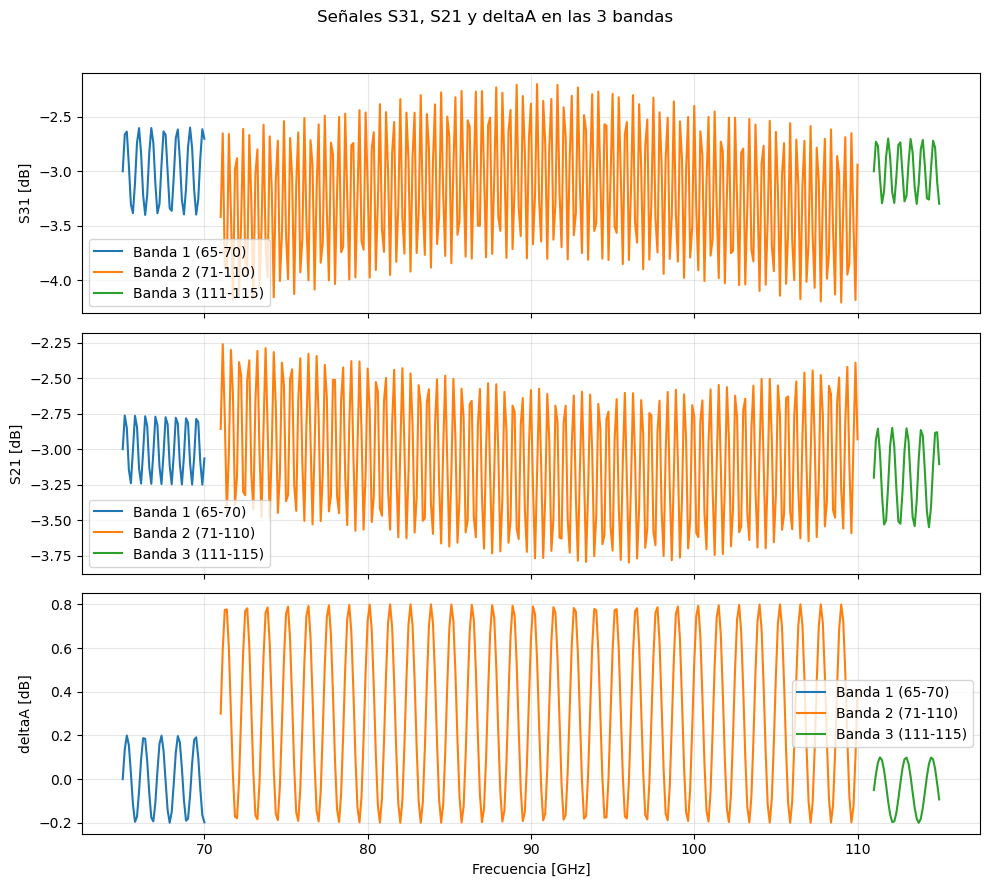

In [28]:
import matplotlib.pyplot as plt
bands = [(65,70), (71,110), (111,115)]
band_labels = ["Banda 1 (65-70)", "Banda 2 (71-110)", "Banda 3 (111-115)"]
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
# plot each signal in its row, color per band
colors = ['C0','C1','C2']
for row, (signal, ylabel) in enumerate([(S31, 'S31 [dB]'), (S21, 'S21 [dB]'), (deltaA, 'deltaA [dB]')]):
    for j, (fmin, fmax) in enumerate(bands):
        mask = (freq >= fmin) & (freq <= fmax)
        if mask.any():
            axes[row].plot(freq[mask], signal[mask], label=band_labels[j], color=colors[j])
    axes[row].set_ylabel(ylabel)
    axes[row].grid(alpha=0.3)
    axes[row].legend(loc='best')
axes[-1].set_xlabel('Frecuencia [GHz]')
plt.suptitle('Señales S31, S21 y deltaA en las 3 bandas')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()